# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

import xgboost as xgb
from xgboost import plot_importance

def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true)**2))

In [6]:
# Load the prepared dataset from Phase 3
DATA_PATH = '../data/processed/rossmann_prepared.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Loaded prepared dataset: 844,392 rows x 22 columns


,store,dayofweek,date,customers,promo,stateholiday,schoolholiday,year,month,day,...,storetype,assortment,competitiondistance,competitionopensincemonth,competitionopensinceyear,promo2,promo2sinceweek,promo2sinceyear,promointerval,sales
0,1,5,2015-07-31,555,1,0,1,2015,7,31,...,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,5263
1,2,5,2015-07-31,625,1,0,1,2015,7,31,...,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",6064
2,3,5,2015-07-31,821,1,0,1,2015,7,31,...,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",8314
3,4,5,2015-07-31,1498,1,0,1,2015,7,31,...,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,13995
4,5,5,2015-07-31,559,1,0,1,2015,7,31,...,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,4822


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [4]:
# TODO: Select and document your modelling techniques here.

modelling_techniques = {
    "problem_type": "Regression",  # We are predicting a continuous numerical value which is Sales
    "target_variable": "sales",
    "candidate_models": [
        {
            "name": "Random Forest Regressor (Baseline)",
            "library": "sklearn.ensemble.RandomForestRegressor",
            "justification": "Serves as a strong baseline model. It handles non-linear relationships well, doesn't require feature scaling, and is robust to outliers.",
            "assumptions": "Assumes features are somewhat informative and that predicting values outside the training data range (extrapolation) isn't heavily required."
        },
        {
            "name": "XGBoost Regressor (Primary)",
            "library": "xgboost.XGBRegressor",
            "justification": "A highly optimized gradient boosting framework designed for speed and performance on large tabular datasets (844k+ rows). It natively handles complex feature interactions like Promo and StoreType.",
            "assumptions": "Assumes hyperparameters will be tuned correctly to prevent the model from memorizing the training data (overfitting)."
        }
    ]
}

# Display the selected techniques
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print(f"\nCandidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']} — {model['justification']}")

Problem Type: Regression
Target Variable: sales

Candidate Models:
  1. Random Forest Regressor (Baseline) — Serves as a strong baseline model. It handles non-linear relationships well, doesn't require feature scaling, and is robust to outliers.
  2. XGBoost Regressor (Primary) — A highly optimized gradient boosting framework designed for speed and performance on large tabular datasets (844k+ rows). It natively handles complex feature interactions like Promo and StoreType.


---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [8]:
# TODO: Define your test design and split the data.

RANDOM_SEED = 42
TEST_SIZE = 0.05 # A 6-week forecast out of 2.5 years of data is roughly 5% 

# Sort chronologically to prevent data leakage
df = df.sort_values('date').reset_index(drop=True)

TARGET_COL = 'sales'
X = df.drop(columns=[TARGET_COL, 'date', 'customers', 'salespercustomer'], errors='ignore') # Drop the target and features not available at prediction time ex: customers
y = np.log1p(df[TARGET_COL]) # Apply log transformation to fix the right-skew

# Perform the train/test split chronologically
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED,
    shuffle=False # the shuffle is false to ensure we train on the past and test on the future
)

print(f"Training set: {X_train.shape[0]:,} samples (Historical Data)")
print(f"Test set:     {X_test.shape[0]:,} samples (Future 6-Weeks)")

Training set: 802,172 samples (Historical Data)
Test set:     42,220 samples (Future 6-Weeks)


In [11]:
# Document and justify your test design
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Chronological Hold-out (Out-of-Time Validation)",
    "stratified": False, # false because this is continuous time-series regression
    "random_seed": RANDOM_SEED,
    "justification": "Since the primary objective is a 6-week advance forecast, a random split would cause data leakage as it would be learning from the future and so we set shuffle as false to train strictly on historical data and validate on the chronological future."
}

for key, value in test_design.items():
    print(f"{key}: {value}")

split_ratio: 95/5
validation_strategy: Chronological Hold-out (Out-of-Time Validation)
stratified: False
random_seed: 42
justification: Since the primary objective is a 6-week advance forecast, a random split would cause data leakage as it would be learning from the future and so we set shuffle as false to train strictly on historical data and validate on the chronological future.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [ ]:
# TODO: Build and train your models.

# Convert categorical text ('a', 'b', 'c') into 1s & 0s for Scikit-Learn
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
print(f"Encoding complete. Features expanded to {X_train.shape[1]} columns.")


trained_models = {}

# --- Model 1: Random Forest ---
print("Training Random Forest Baseline...")

model_1 = RandomForestRegressor(
    random_state=RANDOM_SEED, 
    n_estimators=50, 
    max_depth=15, 
    n_jobs=-1
)
model_1.fit(X_train, y_train)
trained_models['Random Forest'] = model_1
print("Random Forest Baseline trained.")


# --- Model 2: XGBoost ---
print("Training XGBoost...")

model_2 = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    early_stopping_rounds=50,
    eval_metric="rmse",
    n_jobs=-1
)
model_2.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)
trained_models['XGBoost'] = model_2
print(f"XGBoost trained. Best iteration was tree #{model_2.best_iteration}")

print(f"Successfully trained {len(trained_models)} model(s).")

Encoding complete. Features expanded to 26 columns.
Training Random Forest Baseline...
Random Forest Baseline trained.
Training XGBoost...
[0]	validation_0-rmse:0.41821	validation_1-rmse:0.39922
[100]	validation_0-rmse:0.19499	validation_1-rmse:0.18965
[200]	validation_0-rmse:0.14560	validation_1-rmse:0.14535
[300]	validation_0-rmse:0.12946	validation_1-rmse:0.13390
[400]	validation_0-rmse:0.12059	validation_1-rmse:0.12984
[500]	validation_0-rmse:0.11460	validation_1-rmse:0.12726
[600]	validation_0-rmse:0.11044	validation_1-rmse:0.12588
[700]	validation_0-rmse:0.10688	validation_1-rmse:0.12535
[777]	validation_0-rmse:0.10460	validation_1-rmse:0.12539
XGBoost trained. Best iteration was tree #727
Successfully trained 2 model(s).


In [15]:
# Optional: Hyperparameter tuning with GridSearchCV

print("Starting GridSearchCV for XGBoost... (This might take 5-10 minutes)")
start_time = time.time()

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

base_xgb = xgb.XGBRegressor(
    random_state=RANDOM_SEED, 
    n_estimators=150, 
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,  # Use all available CPU cores
    verbose=2   # Show progress in the output
)

grid_search.fit(X_train, y_train)
elapsed_time = (time.time() - start_time) / 60

print(f"Complete tuning in {elapsed_time:.1f} minutes!")
print(f"Best parameters are: {grid_search.best_params_}")
print(f"Best CV score (RMSE): {-grid_search.best_score_:.4f}")

trained_models['XGBoost (Tuned)'] = grid_search.best_estimator_ # Save the best version to our dictionary

Starting GridSearchCV for XGBoost... (This might take 5-10 minutes)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Complete tuning in 0.5 minutes!
Best parameters are: {'learning_rate': 0.1, 'max_depth': 8}
Best CV score (RMSE): 0.1988


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [ ]:
# TODO: Evaluate and compare all trained models.

results = []

y_test_real = np.expm1(y_test)

for name, model in trained_models.items():
    # Predict and un-transform
    y_pred_log = model.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    
    # --- Regression Matrix ---
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test_real, y_pred_real),
        'RMSE': np.sqrt(mean_squared_error(y_test_real, y_pred_real)),
        'RMSPE': rmspe(y_test_real, y_pred_real), 
        'R2': r2_score(y_test_real, y_pred_real)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=== Regression Model Comparison ===")
display(results_df.round(4))

=== Regression Model Comparison ===


,MAE,RMSE,RMSPE,R2
Model,,,,
Random Forest,1115.8167,1648.1712,0.2282,0.7051
XGBoost,636.4304,937.3987,0.1334,0.9046
XGBoost (Tuned),821.1808,1166.0274,0.1713,0.8524



=== Best Model Selected: XGBoost ===


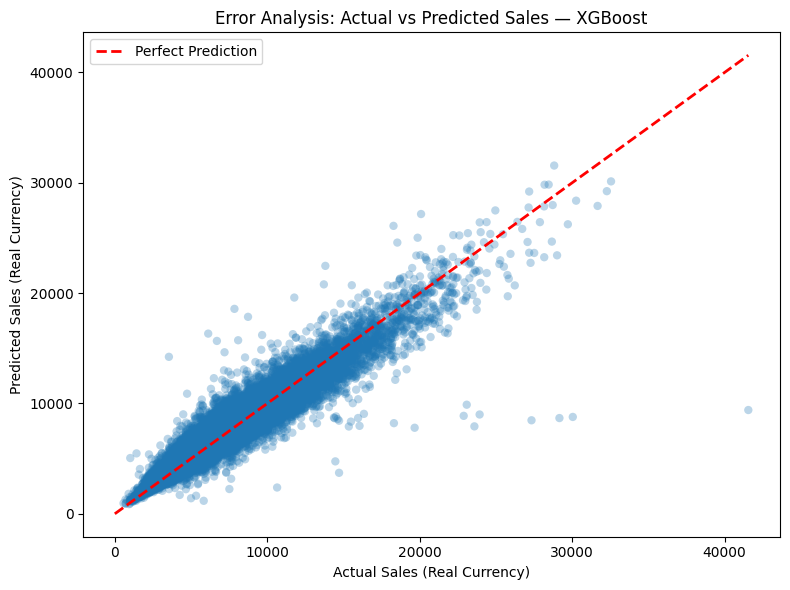

In [17]:
# Visualise results: Actual vs Predicted Sales 

best_model_name = results_df['RMSPE'].idxmin() 
best_model = trained_models[best_model_name]

y_pred_log = best_model.predict(X_test)
y_pred_real = np.expm1(y_pred_log)

print(f"\n=== Best Model Selected: {best_model_name} ===")

# create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, color='#1f77b4', edgecolors='none')

# add the perfect prediction line
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.title(f'Error Analysis: Actual vs Predicted Sales — {best_model_name}')
plt.xlabel('Actual Sales (Real Currency)')
plt.ylabel('Predicted Sales (Real Currency)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation for the selected best model

# We must encode the full X dataset so it matches the 26 columns the model was originally trained on hence removing the raw strings
X_encoded = pd.get_dummies(X)
X_encoded = X_encoded.reindex(columns=X_train.columns, fill_value=0)

best_model.set_params(early_stopping_rounds=None)

print(f"Running Time-Series Cross-Validation for {best_model_name}...")
cv_scores = cross_val_score(
    best_model, X_encoded, y,
    cv=TimeSeriesSplit(n_splits=3), 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Convert negative scikit-learn scores back to positive RMSE
cv_rmse_scores = -cv_scores

print(f"Time-Series CV RMSE Scores: {cv_rmse_scores.round(4)}")
print(f"Mean RMSE: {cv_rmse_scores.mean():.4f} (+/- {cv_rmse_scores.std():.4f})")

best_model.set_params(early_stopping_rounds=50)

Running Time-Series Cross-Validation for XGBoost...
Time-Series CV RMSE Scores: [0.2195 0.1856 0.1628]
Mean RMSE: 0.1893 (+/- 0.0233)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr